## Base plano saúde

# Regressão polinomial

In [1]:
import plotly.express as px
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
base_plano_saude2 = pd.read_csv('plano_saude2.csv')
base_plano_saude2

,idade,custo
0,18,470
1,23,520
2,28,630
3,33,830
4,38,1150
5,43,1530
6,48,2040
7,53,3080
8,58,5100
9,63,10100


In [3]:
X_plano_saude2 = base_plano_saude2.iloc[:, 0:1].values #o x recebe os dados da idade
y_plano_saude2 = base_plano_saude2.iloc[:, 1].values # o y que desejamos prever é o do custo

In [4]:
X_plano_saude2 # atributo preditor, que é a idade.

array([[18],
       [23],
       [28],
       [33],
       [38],
       [43],
       [48],
       [53],
       [58],
       [63]])

In [5]:
y_plano_saude2 # respectivos preços. Regressão polinomial, elevados ao quadrado

array([  470,   520,   630,   830,  1150,  1530,  2040,  3080,  5100,
       10100])

In [6]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree = 2) # degree é quantas vezes desejamos fazer a elevação, no exemplo é elevado ao quadrado apenas
X_plano_saude2_poly = poly.fit_transform(X_plano_saude2)

In [7]:
X_plano_saude2.shape

(10, 1)

In [9]:
X_plano_saude2

array([[18],
       [23],
       [28],
       [33],
       [38],
       [43],
       [48],
       [53],
       [58],
       [63]])

In [10]:
X_plano_saude2_poly # 3 colunas, por padrão a primeira coluna sempre fica 1.

array([[1.000e+00, 1.800e+01, 3.240e+02],
       [1.000e+00, 2.300e+01, 5.290e+02],
       [1.000e+00, 2.800e+01, 7.840e+02],
       [1.000e+00, 3.300e+01, 1.089e+03],
       [1.000e+00, 3.800e+01, 1.444e+03],
       [1.000e+00, 4.300e+01, 1.849e+03],
       [1.000e+00, 4.800e+01, 2.304e+03],
       [1.000e+00, 5.300e+01, 2.809e+03],
       [1.000e+00, 5.800e+01, 3.364e+03],
       [1.000e+00, 6.300e+01, 3.969e+03]])

In [8]:
X_plano_saude2_poly.shape

(10, 3)

In [12]:
18*18 # idade da primeira linha, ao quadrado é igual ao 3.240e+02

324

In [13]:
X_plano_saude2_poly[0]

array([  1.,  18., 324.])

In [14]:
X_plano_saude2_poly[1]

array([  1.,  23., 529.])

In [15]:
#idade de 23 anos
23 * 23

529

In [16]:
# alterando para 4 graus 
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree = 4) # degree é quantas vezes desejamos fazer a elevação, no exemplo é elevado ao 4
X_plano_saude2_poly = poly.fit_transform(X_plano_saude2)

In [17]:
X_plano_saude2_poly.shape


(10, 5)

In [19]:
18 * 18, 18 * 18 * 18, 18 * 18 * 18 * 18  # elevado a 2, a 3 e a 4

(324, 5832, 104976)

In [20]:
X_plano_saude2_poly[0]

array([1.00000e+00, 1.80000e+01, 3.24000e+02, 5.83200e+03, 1.04976e+05])

In [21]:
X_plano_saude2_poly # vamos enviar esses dados para o processo

array([[1.0000000e+00, 1.8000000e+01, 3.2400000e+02, 5.8320000e+03,
        1.0497600e+05],
       [1.0000000e+00, 2.3000000e+01, 5.2900000e+02, 1.2167000e+04,
        2.7984100e+05],
       [1.0000000e+00, 2.8000000e+01, 7.8400000e+02, 2.1952000e+04,
        6.1465600e+05],
       [1.0000000e+00, 3.3000000e+01, 1.0890000e+03, 3.5937000e+04,
        1.1859210e+06],
       [1.0000000e+00, 3.8000000e+01, 1.4440000e+03, 5.4872000e+04,
        2.0851360e+06],
       [1.0000000e+00, 4.3000000e+01, 1.8490000e+03, 7.9507000e+04,
        3.4188010e+06],
       [1.0000000e+00, 4.8000000e+01, 2.3040000e+03, 1.1059200e+05,
        5.3084160e+06],
       [1.0000000e+00, 5.3000000e+01, 2.8090000e+03, 1.4887700e+05,
        7.8904810e+06],
       [1.0000000e+00, 5.8000000e+01, 3.3640000e+03, 1.9511200e+05,
        1.1316496e+07],
       [1.0000000e+00, 6.3000000e+01, 3.9690000e+03, 2.5004700e+05,
        1.5752961e+07]])

In [23]:
from sklearn.linear_model import LinearRegression

regressor_saude_polinomial = LinearRegression() # polinomial adiciona apenas mais dados, não muda o programa.
regressor_saude_polinomial.fit(X_plano_saude2_poly, y_plano_saude2)

LinearRegression()

In [24]:
regressor_saude_polinomial.get_params()

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

In [25]:
# b0 continua
regressor_saude_polinomial.intercept_

16561.974653540092

In [26]:
# b1 (n)
regressor_saude_polinomial.coef_

array([ 0.00000000e+00, -2.12242253e+03,  9.90404200e+01, -1.95058276e+00,
        1.40792541e-02])

In [27]:
novo = [[40]] # novo registro de 40 anos

In [28]:
novo = poly.transform(novo)
novo

array([[1.00e+00, 4.00e+01, 1.60e+03, 6.40e+04, 2.56e+06]])

In [29]:
regressor_saude_polinomial.predict(novo)

array([1335.33958151])

In [30]:
custo_novo = regressor_saude_polinomial.predict(novo)

In [33]:
print(f' O custo para a pessoa com {40} de idade é de $ {custo_novo[0]}')

 O custo para a pessoa com 40 de idade é de $ 1335.3395815141557


In [34]:
# gerar a previsão para todas as bases de dados.

In [35]:
previsoes = regressor_saude_polinomial.predict(X_plano_saude2_poly)
previsoes

array([ 549.65035684,  345.85081742,  616.53846152,  975.83916114,
       1249.06760004, 1472.72727373, 1894.5104895 , 2973.29836636,
       5379.16083513, 9993.35663833])

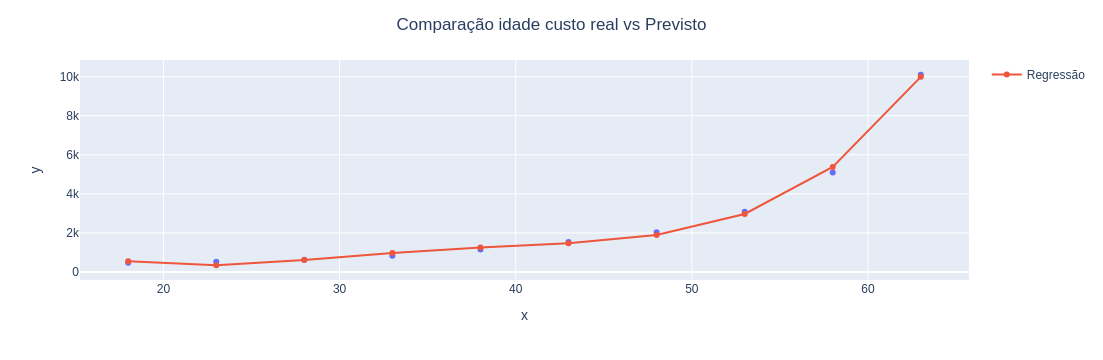

In [37]:
grafico = px.scatter(x = X_plano_saude2[:,0], y = y_plano_saude2)
grafico.add_scatter(x = X_plano_saude2[:,0], y = previsoes, name = 'Regressão')
grafico.update_layout(
        title=f'Comparação idade custo real vs Previsto ',
        title_x=0.5
    )
grafico.show()
grafico.write_html(f"Grafico_custo_idade_saude.html")
